In [1]:
import warnings

import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import torchinfo
from typing import List, Dict, Callable

import time
from collections import defaultdict
from typing import Callable, Dict, List, Tuple, Optional, Union

import numpy as np

import torch
import torch.nn.functional as F
from torchvision.transforms.functional import to_tensor, rgb_to_grayscale
from torch.utils.data import DataLoader
import torchvision.models as models
from collections import defaultdict
import random


from IPython.display import clear_output

sns.set(font_scale=1, style="darkgrid", palette="Set2")
warnings.simplefilter("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

C:\Users\Nataly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


---

В данной задаче вам нужно провести сравнительный анализ сверточных нейросетей с различными параметрами на датасета рукописных цифр MNIST. Использования слоев свертки, pooling более чем достаточно для достижения 97% точности на тесте. Также не делайте сеть глубокой.

In [2]:
# Данные для обучения
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)
# Данные для тестирования
val_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transforms.ToTensor()
)
# Классы объектов в датасете
num_classes = 10
classes_list = [str(i) for i in range(num_classes)]

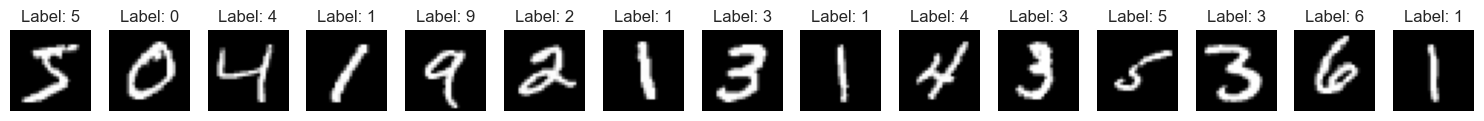

In [5]:
num_images = 15
fig, axs = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):

    image, label = train_dataset[i]

    axs[i].imshow(image.squeeze(), cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f"Label: {label}")

# Плотно размещаем изображения
plt.tight_layout()
plt.show()

In [6]:
image, label = train_dataset[0]
print(image.shape) 

torch.Size([1, 28, 28])


Создайте генераторы батчей.

In [7]:
batch_size = 64  # размер батча

train_batch_gen = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_batch_gen = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

**Эксперимент 1.** Создайте хотя бы 5 сверточных нейросетей с разным количеством линейных и сверточных слоев.

In [103]:
model_1 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=1600, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
).to(device)

torchinfo.summary(model_1, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─MaxPool2d: 1-2                         [1, 32, 13, 13]           --
├─ReLU: 1-3                              [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─MaxPool2d: 1-5                         [1, 64, 5, 5]             --
├─ReLU: 1-6                              [1, 64, 5, 5]             --
├─Flatten: 1-7                           [1, 1600]                 --
├─Linear: 1-8                            [1, 256]                  409,856
├─ReLU: 1-9                              [1, 256]                  --
├─Linear: 1-10                           [1, 10]                   2,570
Total params: 431,242
Trainable params: 431,242
Non-trainable params: 0
Total mult-adds (M): 2.87
Input size (MB): 0.00
Forward/backward pass 

In [104]:
model_2 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Conv2d(in_channels=64, out_channels=512, kernel_size=3, padding=1),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=25088, out_features=10)
).to(device)

torchinfo.summary(model_2, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 28, 28]           640
├─MaxPool2d: 1-2                         [1, 64, 14, 14]           --
├─ReLU: 1-3                              [1, 64, 14, 14]           --
├─Conv2d: 1-4                            [1, 512, 14, 14]          295,424
├─MaxPool2d: 1-5                         [1, 512, 7, 7]            --
├─ReLU: 1-6                              [1, 512, 7, 7]            --
├─Flatten: 1-7                           [1, 25088]                --
├─Linear: 1-8                            [1, 10]                   250,890
Total params: 546,954
Trainable params: 546,954
Non-trainable params: 0
Total mult-adds (M): 58.66
Input size (MB): 0.00
Forward/backward pass size (MB): 1.20
Params size (MB): 2.19
Estimated Total Size (MB): 3.40

In [105]:
model_3 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(3136, 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

torchinfo.summary(model_3, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─ReLU: 1-2                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 32, 14, 14]           --
├─Conv2d: 1-4                            [1, 64, 14, 14]           18,496
├─ReLU: 1-5                              [1, 64, 14, 14]           --
├─MaxPool2d: 1-6                         [1, 64, 7, 7]             --
├─Flatten: 1-7                           [1, 3136]                 --
├─Linear: 1-8                            [1, 128]                  401,536
├─ReLU: 1-9                              [1, 128]                  --
├─Linear: 1-10                           [1, 256]                  33,024
├─ReLU: 1-11                             [1, 256]                  --
├─Linear: 1-12                           [1, 10]                   2,57

In [106]:
model_4 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(6272, 128),
    nn.ReLU(),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
).to(device)

torchinfo.summary(model_4, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─ReLU: 1-2                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 32, 14, 14]           --
├─Flatten: 1-4                           [1, 6272]                 --
├─Linear: 1-5                            [1, 128]                  802,944
├─ReLU: 1-6                              [1, 128]                  --
├─Linear: 1-7                            [1, 32]                   4,128
├─ReLU: 1-8                              [1, 32]                   --
├─Linear: 1-9                            [1, 10]                   330
Total params: 807,722
Trainable params: 807,722
Non-trainable params: 0
Total mult-adds (M): 1.06
Input size (MB): 0.00
Forward/backward pass size (MB): 0.20
Params size (MB): 3.23
Estimated Total Size (MB): 3.44

In [107]:
model_5 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(1152, 512),
    nn.ReLU(),
    nn.Linear(512, 10)
).to(device)

torchinfo.summary(model_5, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─ReLU: 1-2                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 32, 14, 14]           --
├─Conv2d: 1-4                            [1, 64, 14, 14]           18,496
├─ReLU: 1-5                              [1, 64, 14, 14]           --
├─MaxPool2d: 1-6                         [1, 64, 7, 7]             --
├─Conv2d: 1-7                            [1, 128, 7, 7]            73,856
├─ReLU: 1-8                              [1, 128, 7, 7]            --
├─MaxPool2d: 1-9                         [1, 128, 3, 3]            --
├─Flatten: 1-10                          [1, 1152]                 --
├─Linear: 1-11                           [1, 512]                  590,336
├─ReLU: 1-12                             [1, 512]                  --
├

In [11]:
def plot_histories(histories: List[Dict[str, Dict[str, list]]], names: List[str]) -> None:
    """
    Визуализирует лосс и точность для нескольких моделей на одном графике.

    Параметры:
        histories (List[Dict[str, Dict[str, list]]]): Список историй обучения моделей.
            Каждая история должна содержать ключи "loss" и "acc" с подключами "train" и "val".
        names (List[str]): Список названий моделей для легенды.

    Возвращает:
        None
    """
    # Устанавливаем стиль "darkgrid" только для текущего графика
    with sns.axes_style("darkgrid"):
        # Цвета для графиков
        colors = ["darkblue", "lightcoral", "limegreen", "sandybrown", "pink"]

        # Создаем фигуру с двумя подграфиками
        fig, axs = plt.subplots(1, 2, figsize=(14, 5))

        # Определяем количество эпох для отображения (минимальное среди всех историй)
        epochs = np.min([len(h["loss"]["train"]) for h in histories])

        # Построение графиков для каждой модели
        for i, (history, name) in enumerate(zip(histories, names)):
            # График лосса
            axs[0].set_title("Лосс")
            axs[0].plot(
                history["loss"]["train"][:epochs],
                label=f"{name}",
                lw=2,
                c=colors[i],
                ls="--",
            )
            axs[0].plot(
                history["loss"]["val"][:epochs],
                lw=1.5,
                c=colors[i],
            )
            axs[0].set_xlabel("Номер эпохи")

            # График точности
            axs[1].set_title("Точность классификации")
            axs[1].plot(
                history["acc"]["train"][:epochs], label=f"{name}", lw=2, c=colors[i], ls="--"
            )
            axs[1].plot(history["acc"]["val"][:epochs], lw=1.5, c=colors[i])
            axs[1].set_xlabel("Номер эпохи")
            axs[1].legend()

        # Создаем фиктивные линии для легенды (train и val)
        dummy_lines = [
            axs[0].plot([], [], c="black", lw=2, ls="--")[0],
            axs[0].plot([], [], c="black", lw=1.5)[0],
        ]

        # Добавляем легенду для типов линий (train и val)
        for i in range(2):
            legend = axs[i].legend(loc=3 - i)  # Легенда для моделей
            axs[i].legend(dummy_lines, ["train", "val"], loc=4)  # Легенда для типов линий
            axs[i].add_artist(legend)  # Добавляем обе легенды на график

        plt.show()


def print_epoch(epoch, num_epochs, history, t):
    """
    Функция для вывода информации про эпоху.
    :param epoch: номер эпохи
    :param num_epochs: общее количество эпох
    :param history: (dict) accuracy и loss на обучении и валидации ("история" обучения)
    :param t: время эпохи в секундах
    """
    clear_output(wait=True)
    print("Эпоха {} из {}, затраченное время {:.3f} сек.".format(epoch + 1, num_epochs, t))
    print("  лосс на обучении: \t{:.6f}".format(history["loss"]["train"][-1]))
    print("  лосс на валидации: \t{:.6f}".format(history["loss"]["val"][-1]))
    print("  точность на обучении: \t\t{:.2f} %".format(history["acc"]["train"][-1] * 100))
    print("  точность на валидации: \t\t{:.2f} %".format(history["acc"]["val"][-1] * 100))

    # Строим графики лосса и точности
    plot_histories([history], ["Model"])


def update_history(
    history: Dict[str, Dict[str, list]], loss: float, acc: float, num_batches: int, mode: str
) -> None:
    """
    Обновляет историю обучения, добавляя в нее loss и accuracy для текущей эпохи.

    Параметры:
        history (Dict[str, Dict[str, list]]): Словарь с историей обучения.
        loss (float): Суммарный loss за эпоху.
        acc (float): Суммарная точность за эпоху.
        num_batches (int): Количество батчей в эпохе.
        mode (str): Режим обучения ("train" или "val").
    """
    # Нормализуем loss и accuracy по количеству батчей
    loss /= num_batches
    acc /= num_batches
    history["loss"][mode].append(loss)
    history["acc"][mode].append(acc)


def get_batch_loss(
    X_batch: torch.Tensor,
    y_batch: torch.Tensor,
    model: nn.Module,
    criterion: Callable,
    current_loss: float,
    current_acc: float,
) -> Tuple[torch.Tensor, float, float]:
    """
    Вычисляет loss и accuracy для одного батча (без backward pass).

    Параметры:
        X_batch (torch.Tensor): Батч входных данных.
        y_batch (torch.Tensor): Батч меток.
        model (nn.Module): Модель для обучения (выдает логиты).
        criterion (Callable): Функция потерь.
        current_loss (float): Текущий лосс за батч.
        current_acc (float): Текущая точность за батч.

    Возвращает:
        Tuple[torch.Tensor, float, float]: Лосс на батче, обновленные суммарные loss и accuracy.
    """
    # Перемещаем данные на устройство (GPU/CPU)
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    # Получаем логиты от модели
    logits = model(X_batch)

    # Вычисляем loss
    loss = criterion(logits, y_batch.long().to(device))

    # Сохраняем лоссы и точность
    current_loss += loss.detach().cpu().numpy()
    y_pred = logits.max(1)[1].detach().cpu().numpy()
    current_acc += np.mean(y_batch.cpu().numpy() == y_pred)
    return loss, current_loss, current_acc


def train(
    model: nn.Module,
    criterion: Callable,
    optimizer: optim.Optimizer,
    train_batch_gen: DataLoader,
    val_batch_gen: DataLoader,
    num_epochs: int = 40,
) -> Dict[str, Dict[str, list]]:
    """
    Обучает модель и возвращает историю обучения.

    Параметры:
        model (nn.Module): Модель для обучения.
        criterion (Callable): Функция потерь.
        optimizer (optim.Optimizer): Оптимизатор.
        train_batch_gen (DataLoader): Генератор батчей для обучения.
        val_batch_gen (DataLoader): Генератор батчей для валидации.
        num_epochs (int): Количество эпох (по умолчанию 40).

    Возвращает:
        Dict[str, Dict[str, list]]: История обучения, содержащая loss и accuracy для обучения и валидации.
    """
    history = defaultdict(lambda: defaultdict(list))

    for epoch in range(num_epochs):
        train_loss, val_loss = 0, 0
        train_acc, val_acc = 0, 0
        start_time = time.time()

        # ----------------------   ОБУЧЕНИЕ   ----------------------#
        model.train(True)

        # На каждой "эпохе" делаем полный проход по данным
        for X_batch, y_batch in train_batch_gen:

            # Вычисляем loss и accuracy для батча
            loss, train_loss, train_acc = get_batch_loss(
                X_batch, y_batch, model, criterion, train_loss, train_acc
            )

            # Обратный проход, вычисление градиентов
            loss.backward()
            # Шаг градиентного спуска для обновления оценок весов
            optimizer.step()
            # Зануление градиентов
            optimizer.zero_grad()

        # Обновляем историю обучения
        update_history(history, train_loss, train_acc, len(train_batch_gen), "train")

        # ----------------------   ВАЛИДАЦИЯ   ----------------------#
        model.train(False)

        # Контекстный менеджер, отключающий подсчет градиентов
        with torch.no_grad():
            # Полный проход по валидационному датасету
            for X_batch, y_batch in val_batch_gen:
                # Вычисляем loss и accuracy для батча
                _, val_loss, val_acc = get_batch_loss(
                    X_batch, y_batch, model, criterion, val_loss, val_acc
                )

        # Обновляем историю валидации
        update_history(history, val_loss, val_acc, len(val_batch_gen), "val")

        # Выводим информацию о текущей эпохе
        print_epoch(epoch, num_epochs, history, time.time() - start_time)

    return history

Обучите сети, используя функцию потерь `nn.CrossEntropyLoss` и оптимизатор `torch.optim.SGD` с дефолтными параметрами.

Эпоха 40 из 40, затраченное время 52.515 сек.
  лосс на обучении: 	0.110369
  лосс на валидации: 	0.103299
  точность на обучении: 		96.82 %
  точность на валидации: 		96.95 %


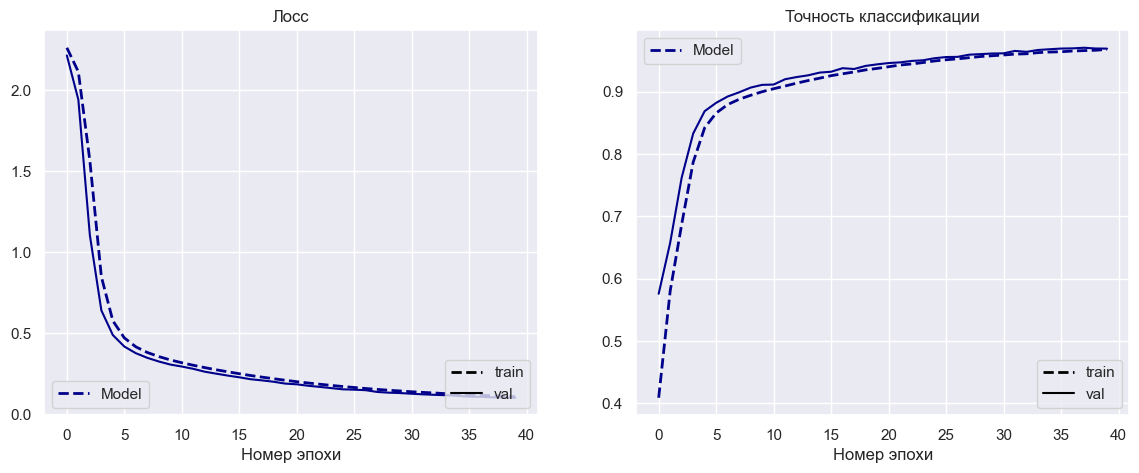

In [109]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters())

history_1 = train(model_1, criterion, optimizer, train_batch_gen, val_batch_gen)
torch.save(model_1.state_dict(), "model_1.pth")

Эпоха 40 из 40, затраченное время 239.531 сек.
  лосс на обучении: 	0.093022
  лосс на валидации: 	0.084256
  точность на обучении: 		97.40 %
  точность на валидации: 		97.63 %


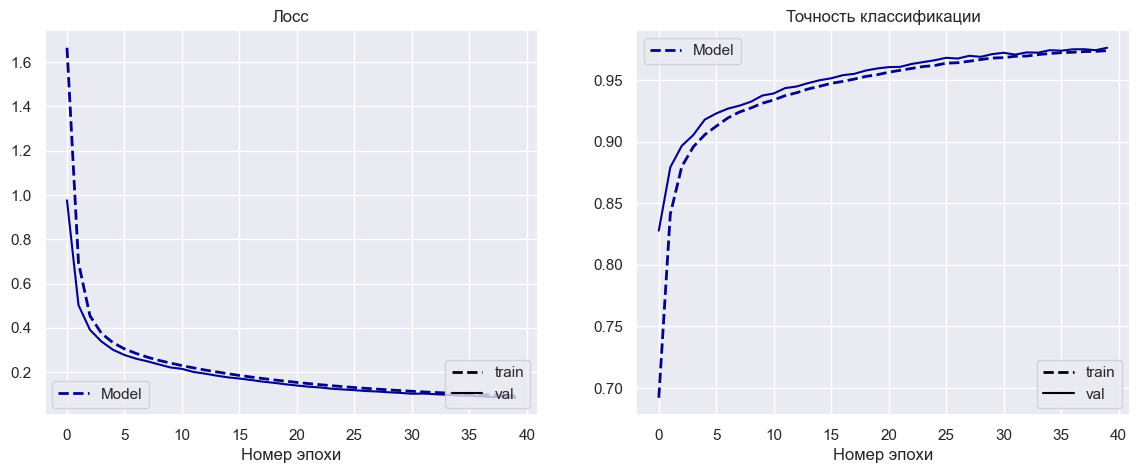

In [110]:
optimizer = torch.optim.SGD(model_2.parameters())

history_2 = train(model_2, criterion, optimizer, train_batch_gen, val_batch_gen)

torch.save(model_2.state_dict(), "model_2.pth")

Эпоха 40 из 40, затраченное время 57.959 сек.
  лосс на обучении: 	0.116417
  лосс на валидации: 	0.104459
  точность на обучении: 		96.54 %
  точность на валидации: 		96.83 %


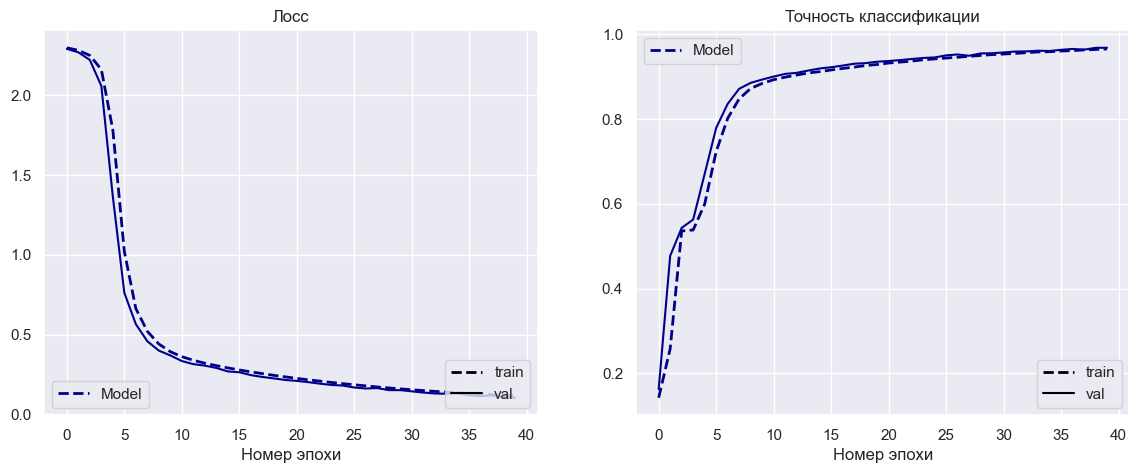

In [111]:
optimizer = torch.optim.SGD(model_3.parameters())

history_3 = train(model_3, criterion, optimizer, train_batch_gen, val_batch_gen)

torch.save(model_3.state_dict(), "model_3.pth")

Эпоха 40 из 40, затраченное время 50.006 сек.
  лосс на обучении: 	0.203128
  лосс на валидации: 	0.191855
  точность на обучении: 		94.03 %
  точность на валидации: 		94.35 %


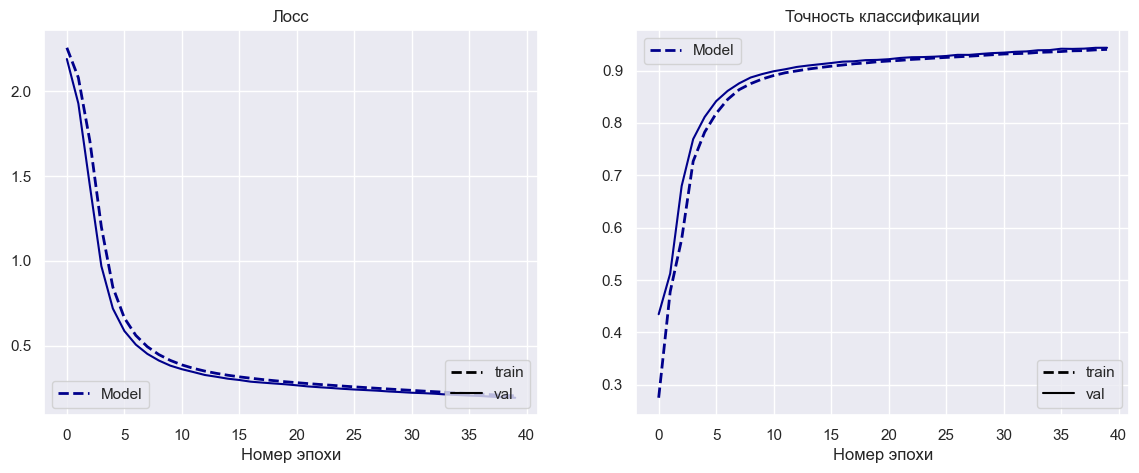

In [112]:
optimizer = torch.optim.SGD(model_4.parameters())

history_4 = train(model_4, criterion, optimizer, train_batch_gen, val_batch_gen)

torch.save(model_4.state_dict(), "model_4.pth")

Эпоха 40 из 40, затраченное время 71.836 сек.
  лосс на обучении: 	0.096219
  лосс на валидации: 	0.095933
  точность на обучении: 		97.04 %
  точность на валидации: 		96.96 %


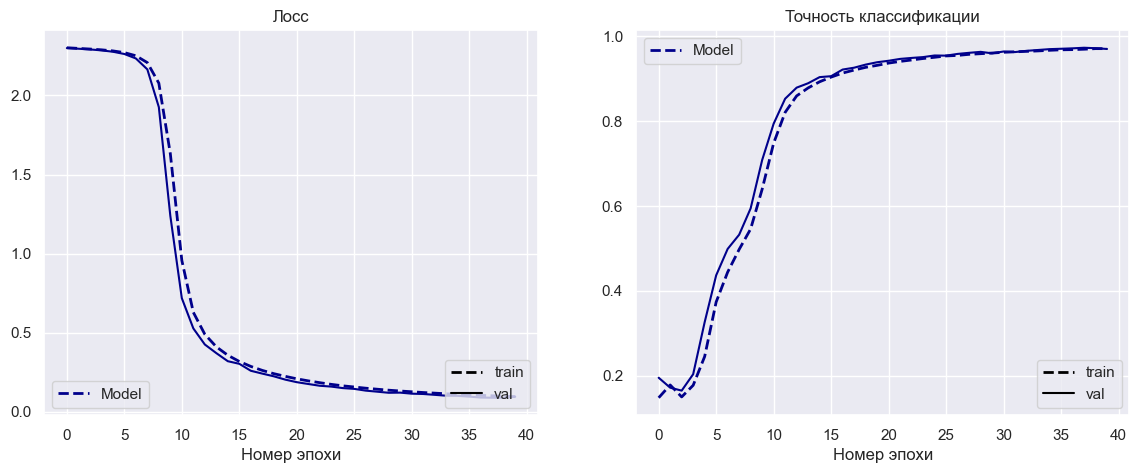

In [113]:
optimizer = torch.optim.SGD(model_5.parameters())

history_5 = train(model_5, criterion, optimizer, train_batch_gen, val_batch_gen)

torch.save(model_5.state_dict(), "model_5.pth")

Постройте график лосса и график accuracy, где сравниваются все модели (на train и на val).

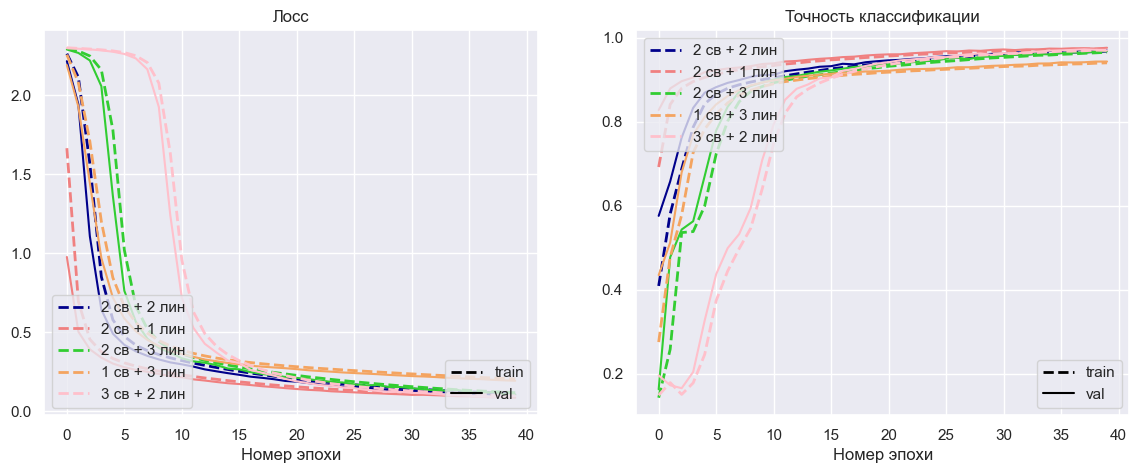

In [117]:
plot_histories([history_1, history_2, history_3, history_4, history_5], ["2 св + 2 лин", "2 св + 1 лин", "2 св + 3 лин", "1 св + 3 лин", "3 св + 2 лин"])

In [148]:
histories = [history_1, history_2, history_3, history_4, history_5]
names = ["2 св + 2 лин", "2 св + 1 лин", "2 св + 3 лин", "1 св + 3 лин", "3 св + 2 лин"]

# в историю время не сохранчлось, переучивать очень долго, поэтому я просто взяла время из ячеек
train_times = [1978, 9528, 2485, 1926, 3080]
rows = []

for name, hist, time_sec in zip(names, histories, train_times):
    train_acc = hist["acc"]["train"][-1]
    val_acc = hist["acc"]["val"][-1]
    rows.append({
        "Model": name,
        "Train accuracy (%)": train_acc * 100,
        "Validation accuracy (%)": val_acc * 100,
        "Train time (sec)": time_sec
    })

df = pd.DataFrame(rows)
print(df)


          Model  Train accuracy (%)  Validation accuracy (%)  Train time (sec)
0  2 св + 2 лин           96.821695                96.954618              1978
1  2 св + 1 лин           97.398054                97.631369              9528
2  2 св + 3 лин           96.540179                96.825239              2485
3  1 св + 3 лин           94.029851                94.347134              1926
4  3 св + 2 лин           97.041578                96.964570              3080


Самая высокаая точность у второй модели, но она потртила больше всех времени. Для меня это довольно странно, потому что в некоторых моделях есть большее количество слоев и большее количество параметров. Одного сверточного слоя мало, это видно по предпоследней модели, у нее самая низкая точность, добавление третьего тоже не имеет особой выгоды (последняя модель). Может быть это случайность, но добавление третьего линейного слоя тоже не повысило точность. Я не могу объяснить почему обучние второй модели заняло столько времени (будем считать, что компьютер начал выполнять какие-то другие операции параллельно с этой задачей), но по остальным моделям явно видно, что добавление дополнительных слоев увеличиват время обучения. Для второго эксперимента я возьму первую модель, хотя она не лучше всех с точки зрения точности, на мой взгляд она лучшая в сообношении точность-время. 

**Эксперимент 2.** Теперь выберите лучший вариант, зафиксируйте это количество сверточных и линейных слоев и обучите хотя бы 4 сверточных нейросети, варьируя размеры ядер сверток. Например, в разном порядке поставьте ядра 3x3, 5x5.

In [136]:
model_1_1 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=1600, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
).to(device)

torchinfo.summary(model_1_1, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─MaxPool2d: 1-2                         [1, 32, 13, 13]           --
├─ReLU: 1-3                              [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─MaxPool2d: 1-5                         [1, 64, 5, 5]             --
├─ReLU: 1-6                              [1, 64, 5, 5]             --
├─Flatten: 1-7                           [1, 1600]                 --
├─Linear: 1-8                            [1, 256]                  409,856
├─ReLU: 1-9                              [1, 256]                  --
├─Linear: 1-10                           [1, 10]                   2,570
Total params: 431,242
Trainable params: 431,242
Non-trainable params: 0
Total mult-adds (M): 2.87
Input size (MB): 0.00
Forward/backward pass 

In [140]:
model_1_2 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=1024, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
).to(device)

torchinfo.summary(model_1_2, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─MaxPool2d: 1-2                         [1, 32, 13, 13]           --
├─ReLU: 1-3                              [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 9, 9]             51,264
├─MaxPool2d: 1-5                         [1, 64, 4, 4]             --
├─ReLU: 1-6                              [1, 64, 4, 4]             --
├─Flatten: 1-7                           [1, 1024]                 --
├─Linear: 1-8                            [1, 256]                  262,400
├─ReLU: 1-9                              [1, 256]                  --
├─Linear: 1-10                           [1, 10]                   2,570
Total params: 316,554
Trainable params: 316,554
Non-trainable params: 0
Total mult-adds (M): 4.63
Input size (MB): 0.00
Forward/backward pass 

In [141]:
model_1_3 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=1600, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
).to(device)

torchinfo.summary(model_1_3, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 24, 24]           832
├─MaxPool2d: 1-2                         [1, 32, 12, 12]           --
├─ReLU: 1-3                              [1, 32, 12, 12]           --
├─Conv2d: 1-4                            [1, 64, 10, 10]           18,496
├─MaxPool2d: 1-5                         [1, 64, 5, 5]             --
├─ReLU: 1-6                              [1, 64, 5, 5]             --
├─Flatten: 1-7                           [1, 1600]                 --
├─Linear: 1-8                            [1, 256]                  409,856
├─ReLU: 1-9                              [1, 256]                  --
├─Linear: 1-10                           [1, 10]                   2,570
Total params: 431,754
Trainable params: 431,754
Non-trainable params: 0
Total mult-adds (M): 2.74
Input size (MB): 0.00
Forward/backward pass 

In [143]:
model_1_4 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5),
    nn.MaxPool2d(2),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=1024, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
).to(device)

torchinfo.summary(model_1_4, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 24, 24]           832
├─MaxPool2d: 1-2                         [1, 32, 12, 12]           --
├─ReLU: 1-3                              [1, 32, 12, 12]           --
├─Conv2d: 1-4                            [1, 64, 8, 8]             51,264
├─MaxPool2d: 1-5                         [1, 64, 4, 4]             --
├─ReLU: 1-6                              [1, 64, 4, 4]             --
├─Flatten: 1-7                           [1, 1024]                 --
├─Linear: 1-8                            [1, 256]                  262,400
├─ReLU: 1-9                              [1, 256]                  --
├─Linear: 1-10                           [1, 10]                   2,570
Total params: 317,066
Trainable params: 317,066
Non-trainable params: 0
Total mult-adds (M): 4.03
Input size (MB): 0.00
Forward/backward pass 

Эпоха 40 из 40, затраченное время 34.530 сек.
  лосс на обучении: 	0.111430
  лосс на валидации: 	0.098597
  точность на обучении: 		96.74 %
  точность на валидации: 		97.19 %


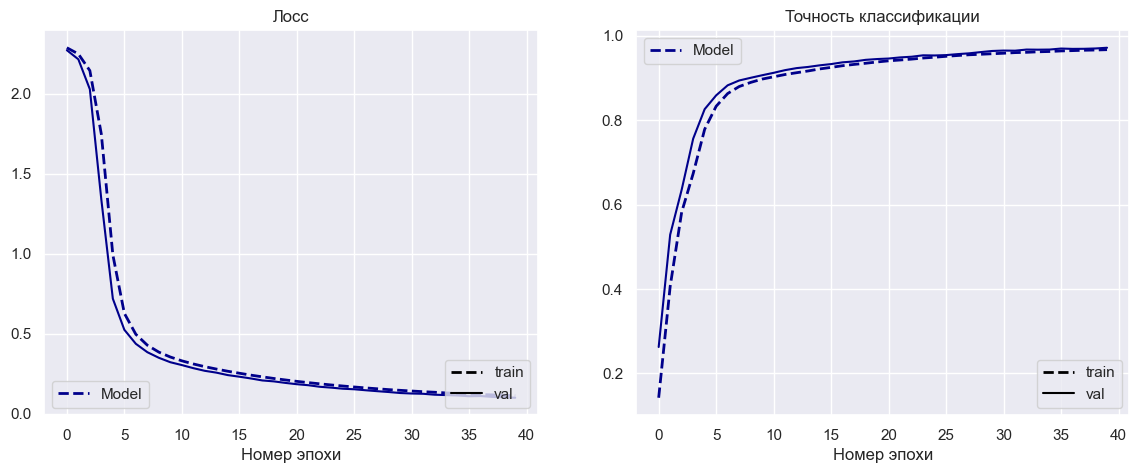

In [144]:
optimizer = torch.optim.SGD(model_1_1.parameters())

history_1_1 = train(model_1_1, criterion, optimizer, train_batch_gen, val_batch_gen)

torch.save(model_1_1.state_dict(), "model_1_1.pth")

Эпоха 40 из 40, затраченное время 37.830 сек.
  лосс на обучении: 	0.106010
  лосс на валидации: 	0.094836
  точность на обучении: 		96.83 %
  точность на валидации: 		97.18 %


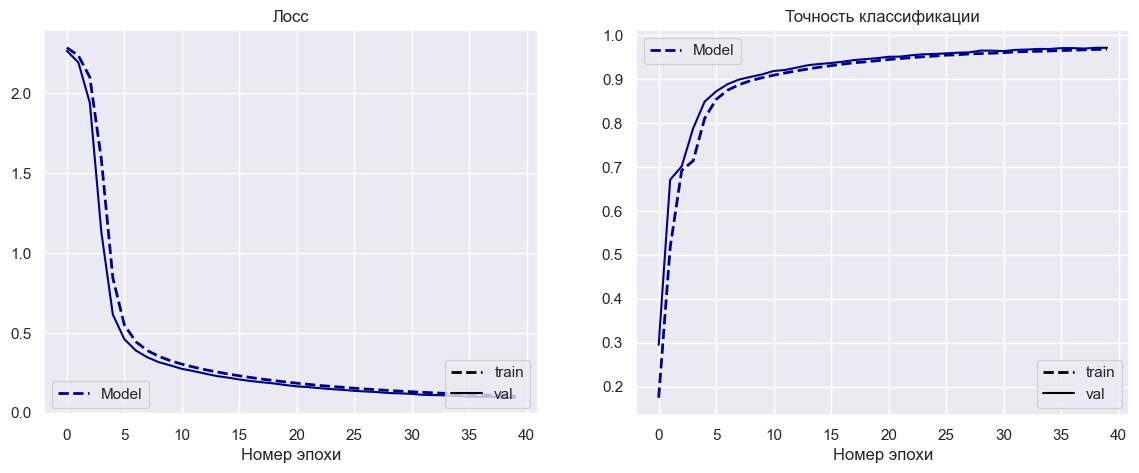

In [145]:
optimizer = torch.optim.SGD(model_1_2.parameters())

history_1_2 = train(model_1_2, criterion, optimizer, train_batch_gen, val_batch_gen)

torch.save(model_1_2.state_dict(), "model_1_2.pth")

Эпоха 40 из 40, затраченное время 52.134 сек.
  лосс на обучении: 	0.100824
  лосс на валидации: 	0.088185
  точность на обучении: 		97.02 %
  точность на валидации: 		97.46 %


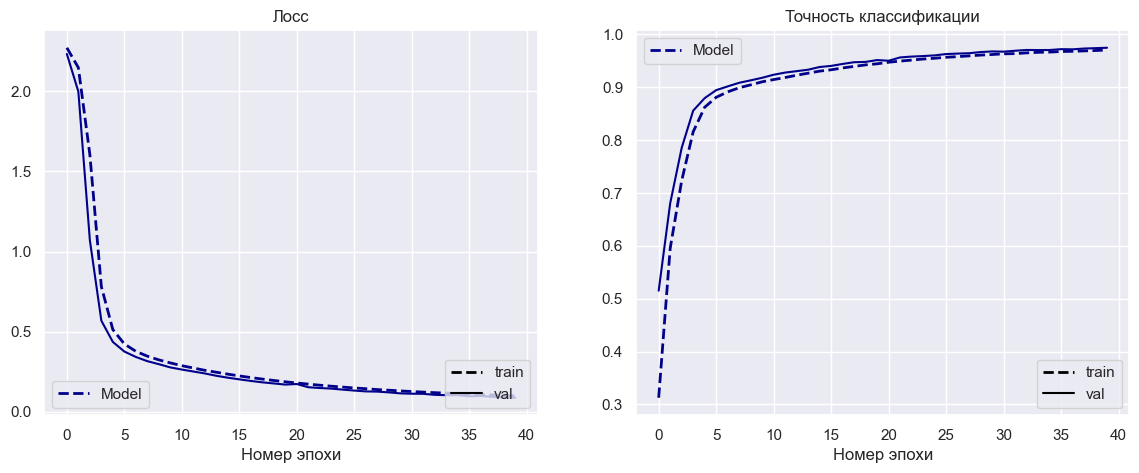

In [146]:
optimizer = torch.optim.SGD(model_1_3.parameters())

history_1_3 = train(model_1_3, criterion, optimizer, train_batch_gen, val_batch_gen)

torch.save(model_1_3.state_dict(), "model_1_3.pth")

Эпоха 40 из 40, затраченное время 51.403 сек.
  лосс на обучении: 	0.098177
  лосс на валидации: 	0.085377
  точность на обучении: 		97.11 %
  точность на валидации: 		97.63 %


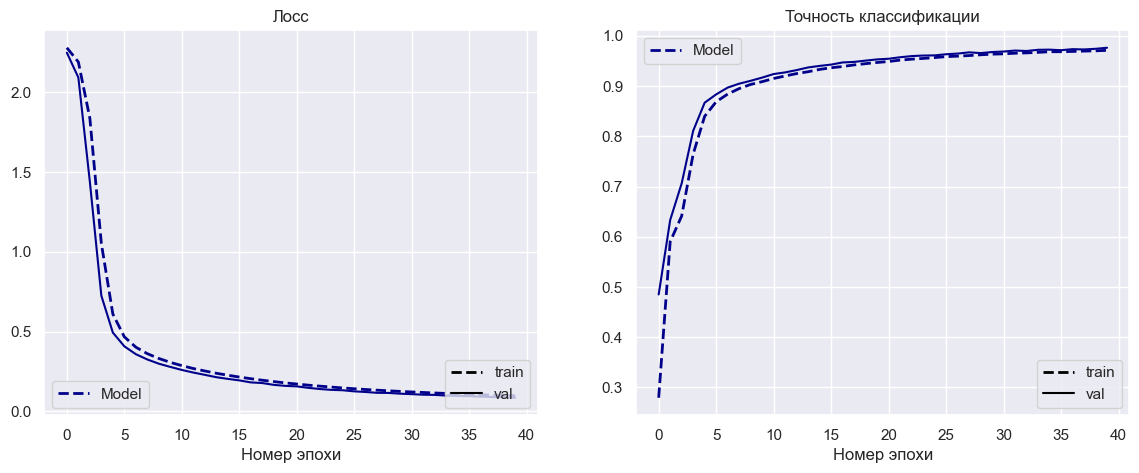

In [147]:
optimizer = torch.optim.SGD(model_1_4.parameters())

history_1_4 = train(model_1_4, criterion, optimizer, train_batch_gen, val_batch_gen)

torch.save(model_1_4.state_dict(), "model_1_4.pth")

Постройте график лосса и график accuracy, где сравниваются все модели этого эксперимента (на train и на val).

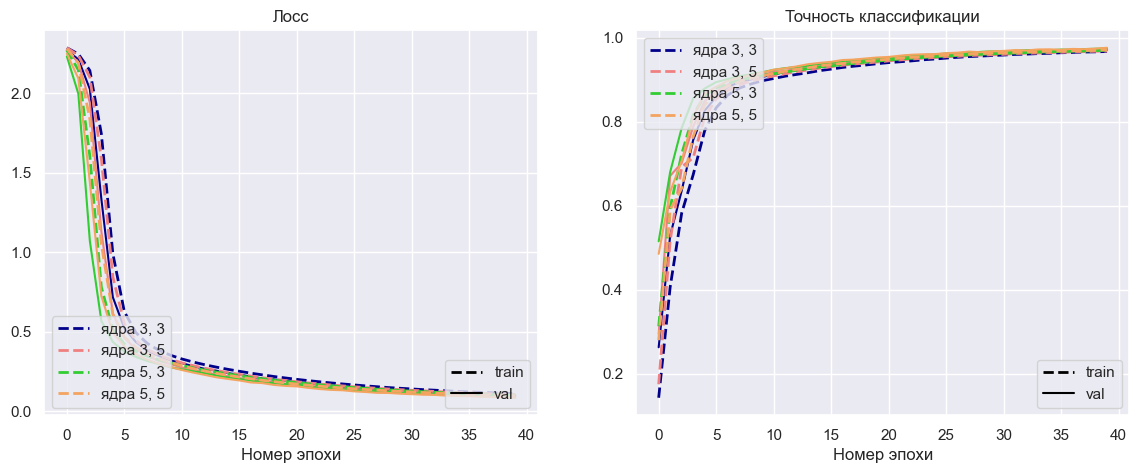

In [149]:
plot_histories([history_1_1, history_1_2, history_1_3, history_1_4], ["ядра 3, 3", "ядра 3, 5", "ядра 5, 3", "ядра 5, 5"])

In [ ]:
histories = [history_1_1, history_1_2, history_1_3, history_1_4]
names = ["ядра 3, 3", "ядра 3, 5", "ядра 5, 3", "ядра 5, 5"]

train_times = [1760, 1466, 1384, 1826]
rows = []

for name, hist, time_sec in zip(names, histories, train_times):
    train_acc = hist["acc"]["train"][-1]
    val_acc = hist["acc"]["val"][-1]
    rows.append({
        "Model": name,
        "Train accuracy (%)": train_acc * 100,
        "Validation accuracy (%)": val_acc * 100,
        "Train time (sec)": time_sec
    })

df = pd.DataFrame(rows)
print(df)

       Model  Train accuracy (%)  Validation accuracy (%)  Train time (sec)
0  ядра 3, 3           96.738406                97.193471              1760
1  ядра 3, 5           96.830024                97.183519              1466
2  ядра 5, 3           97.023254                97.462182              1384
3  ядра 5, 5           97.114872                97.631369              1826


При использовании более крупных ядер точность получается выше. Логически модели с меньшими ядрами должны учиться за большее время, но в моей ситуации модели, где ядра одинаковые учатся дольше чем модели, гдк ядра разные. Для третьего эксперимента я буду использовать последнюю модель.

Выберите лучшую конфигурацию из всех по accuracy на валидации. Проведите еще один проход валидации выбранной моделью по всему датасету. В нем посчитайте точность по каждому классу и соберите информацию о неправильных предсказаниях.

In [ ]:
model_1_4.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_batch_gen:

        outputs = model_1_4(X_batch)
        predicted = outputs.argmax(dim=1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [158]:
class_predictions = {cls: [] for cls in range(10)}

for i in range(len(y_true)):
    true_class = y_true[i]
    predicted_class = y_pred[i]
    class_predictions[true_class].append((i, predicted_class))

Равномерна ли точность по отношению к классам? 

In [162]:
class_accuracy = {}

for cls, predictions in class_predictions.items():
    total = len(predictions)
    incorrect = sum(1 for index, pred in predictions if pred != cls)

    accuracy = ((total - incorrect) / total) * 100
    class_accuracy[cls] = accuracy

accuracy_df = pd.DataFrame(list(class_accuracy.items()), columns=['Class', 'Accuracy'])
print(accuracy_df)

   Class   Accuracy
0      0  98.979592
1      1  99.030837
2      2  97.577519
3      3  97.425743
4      4  98.268839
5      5  97.645740
6      6  97.912317
7      7  96.887160
8      8  96.509240
9      9  95.837463


Покажите 10-20 примеров, на которых нейросеть выдала неправильную метку. Что можно о них сказать?

In [166]:
errors = {cls: [] for cls in range(10)}

for index, (true_label, pred_label) in enumerate(zip(y_true, y_pred)):
    if true_label != pred_label:
        errors[true_label].append((index, true_label, pred_label))

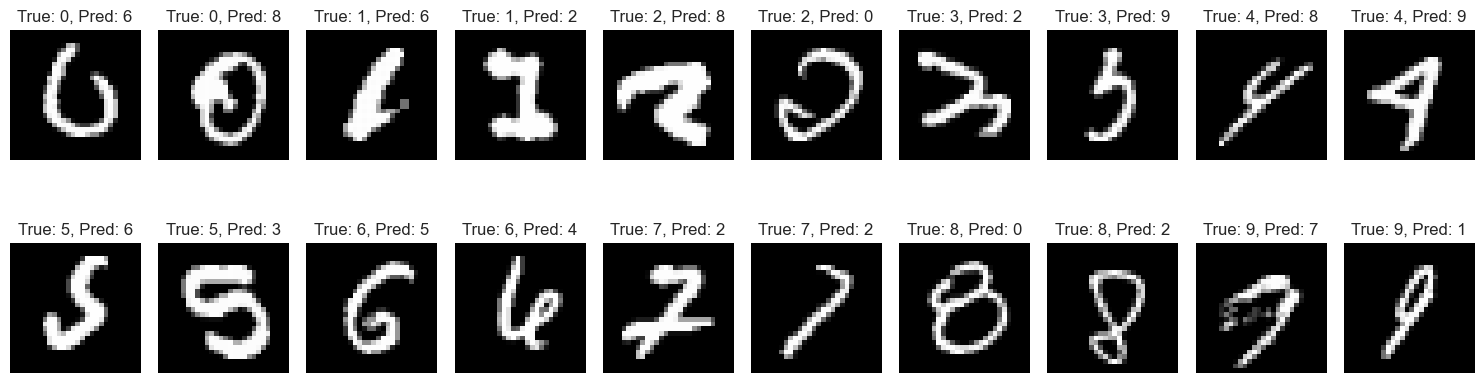

In [171]:
plt.figure(figsize=(15, 5))

index = 1
for cls in range(10):
    error_samples = random.sample(errors[cls], 2)
    
    for img_index, true_label, pred_label in error_samples:

        img = val_dataset[img_index][0].numpy().squeeze()

        plt.subplot(2, 10, index)
        plt.imshow(img, cmap="gray")
        plt.title(f"True: {true_label}, Pred: {pred_label}")
        plt.axis('off')
        index += 1

plt.tight_layout()
plt.show()


Лучше всех определяются 1 и 4, хуже всего на 8 и 9. Разница в точности примерно 3-3,5%, мне кажется это достаточно существенно. Думаю это связано с тем, что некоторые цифры гораздо более "особенные". То есть доволльно сложно перепутать 4 с чем-то, но иногда грань между шестеркой и восьмеркой, например, довольно тонкая.
Про ошибки можно сказать, что они очень специфичекие, про некоторые я не могу точно сказать, к какому классу я бы отнесла конкретную картинку. Я предполагаю, что на более или менее нормально напсанных цифрах модель работает хорошо.

Для решения задачи классификации цифр сверточные нейросети подходят достаточно хорошо. Не имеет особо смысла добавлять слишком много слоев, от этого точность не становится выше. Не стоит использовать слишком маленькие ядра (предполагаю как и слишком большие), от этого модель тоже теряет точность. Думаю, что для разных задач нужна сильно разная архитектура (например в ноутбуке с занятия использовались дркгие параметры, и может быть для конкретной задачи они подходили лучше). Есть некая точность в точности предсказаний из разных классов (это тоже логично, потому что некоторые классы довольно сильно похожи между собой, а другие не очень).

На первом занятии</a> мы рассматривали классификацию с помощью KNN, который показал высокую точность — 99%. Возникает вопрос: зачем нам изучать более сложные методы, если простой KNN может работать так же хорошо или даже лучше?

Когда мы искользовали метод ближайшего соседа мы сильно сжимали данные, из-за этого было сильно меньше признаков. И в целом kNN не очень хороший метод, потому что, во-первых, ему нужно вычислять расстояние для каждого из элементов выборки, это очень долго, он скорее всего будет плохо работать с данными где большие размерности (это на 7 занятии разбирали, проклятие размерности называется). И ещё например, если одинаково нарисованы цифры одна с правой части картинки, другая - с левой, то kNN это не распознает нормально. Ну то есть цифры это не очень сложная задача, поэтому получилась высокая точность, но для более сложных задач, скорее всего, так не повезет.

---

Обучите модель, состоящую как минимум из 4 сверточных слоев, на датасете MNIST.


In [12]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.Conv2d(32, 32, kernel_size=5, padding=1),
    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(5408, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

torchinfo.summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─ReLU: 1-2                              [1, 32, 28, 28]           --
├─Conv2d: 1-3                            [1, 32, 28, 28]           9,248
├─ReLU: 1-4                              [1, 32, 28, 28]           --
├─Conv2d: 1-5                            [1, 32, 28, 28]           9,248
├─ReLU: 1-6                              [1, 32, 28, 28]           --
├─Conv2d: 1-7                            [1, 32, 26, 26]           25,632
├─ReLU: 1-8                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-9                         [1, 32, 13, 13]           --
├─Flatten: 1-10                          [1, 5408]                 --
├─Linear: 1-11                           [1, 128]                  692,352
├─ReLU: 1-12                             [1, 128]                  --

Эпоха 40 из 40, затраченное время 172.502 сек.
  лосс на обучении: 	0.042243
  лосс на валидации: 	0.058777
  точность на обучении: 		98.70 %
  точность на валидации: 		98.17 %


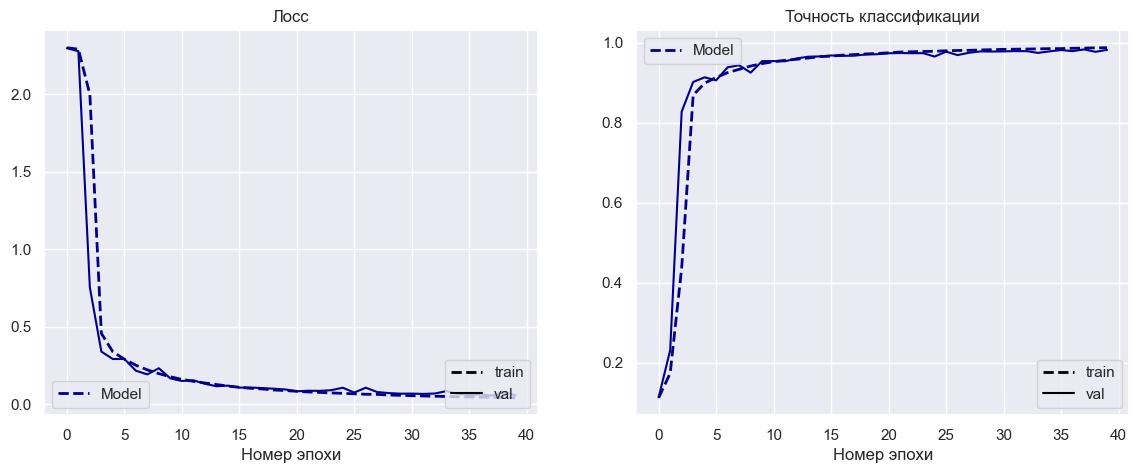

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters())

history_1 = train(model, criterion, optimizer, train_batch_gen, val_batch_gen)
torch.save(model.state_dict(), "model.pth")

Визуализируйте веса свертки на первом слое. Поскольку веса имеют размерность $(32, 1, K_1, K_2)$, т.к. входное изображение имеет один канал, вам необходимо отобразить 32 изображения (по количеству выходных каналов) фильтрами размера $K_1 \times K_2$.

*Совет.* Здесь и далее серии из 32 картинок визуализируйте в виде сетки с помощью `plt.subplots(4, 8, figsize=...)`. Не забывайте указывать параметр `cmap='gray'`.

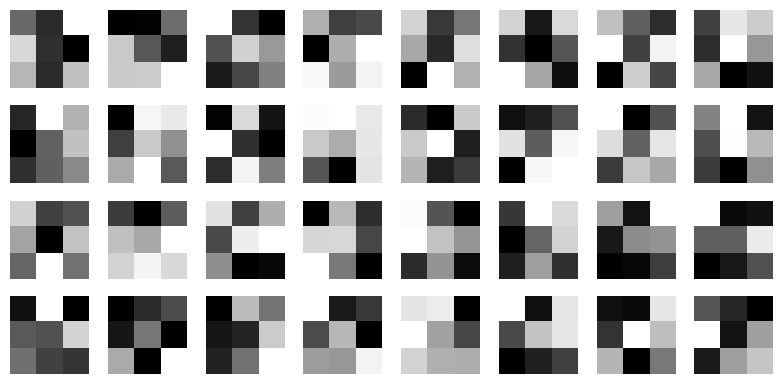

In [17]:
first_conv_weights = model[0].weight.data.cpu().numpy()

fig, axes = plt.subplots(4, 8, figsize=(8, 4))

for i, ax in enumerate(axes.flat):
    weight = first_conv_weights[i, 0, :, :]
    ax.imshow(weight, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

Какую функцию они могут нести? 

Эти веса похожи на границы или углы цифр или какие-то индивидуальные мелкие особенности. На фильтры Гаусса, на мой взгляд, они совсем не похожи. Поэтому, скорее всего, они нужны для определения границ цифр.

Для одного произвольного изображения из датасета MNIST визуализируйте выходы **всех слоев** нейросети, включая активацию и пуллинг, вплоть до операции `Flatten`, но не включая её.

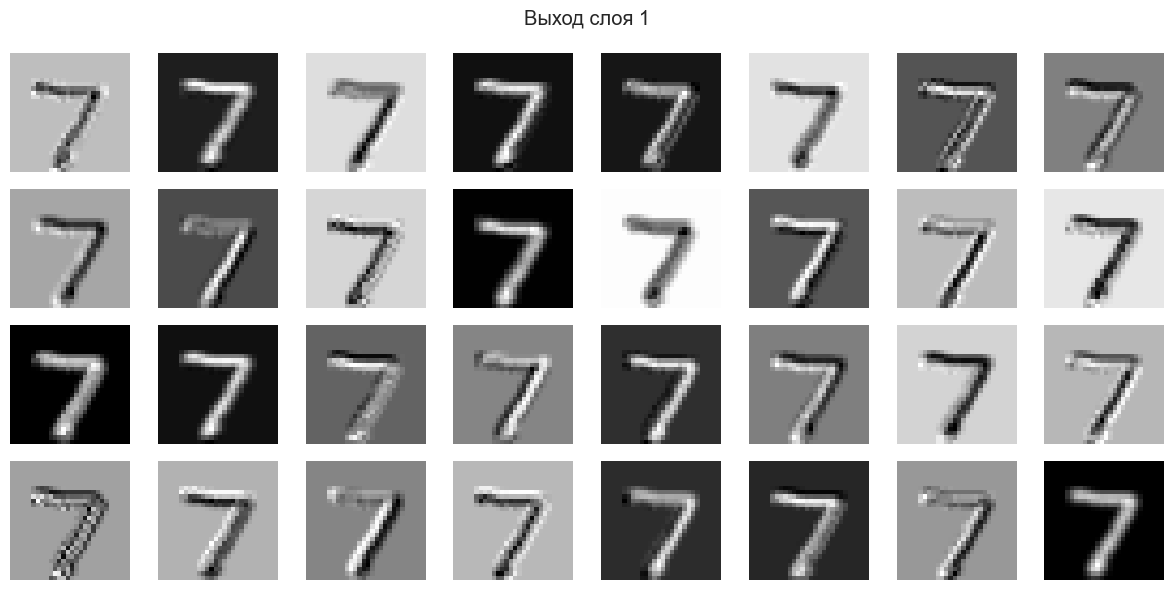

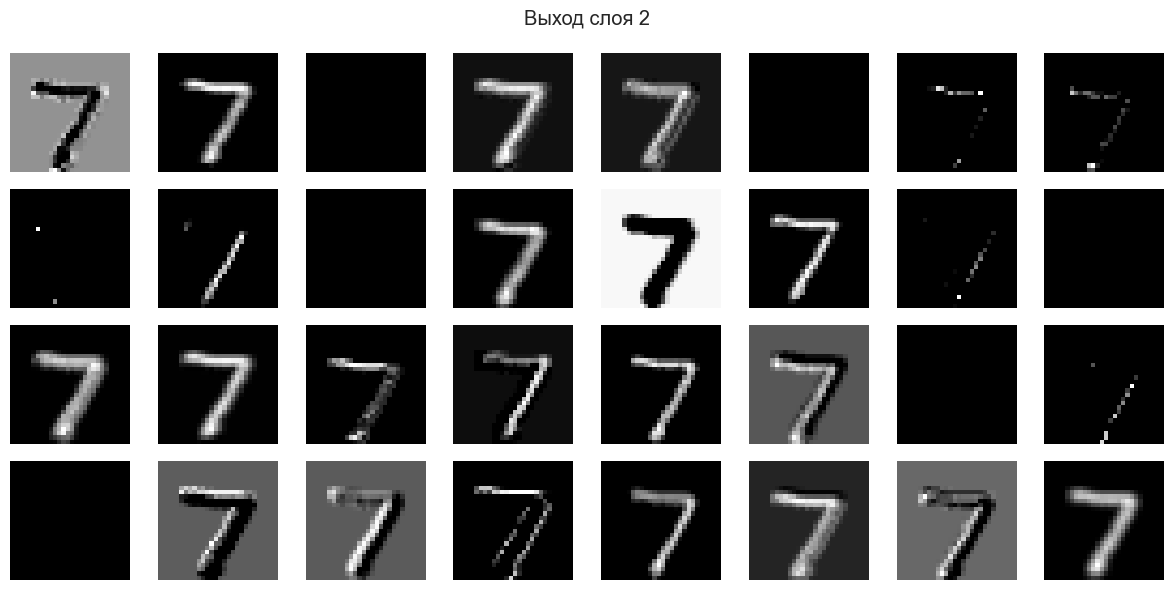

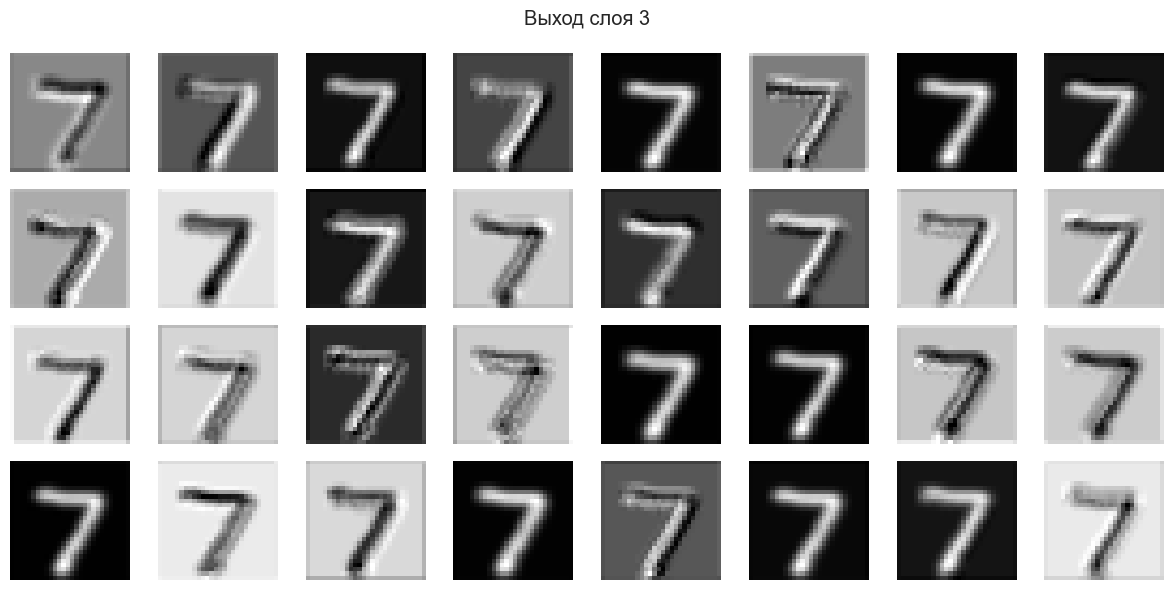

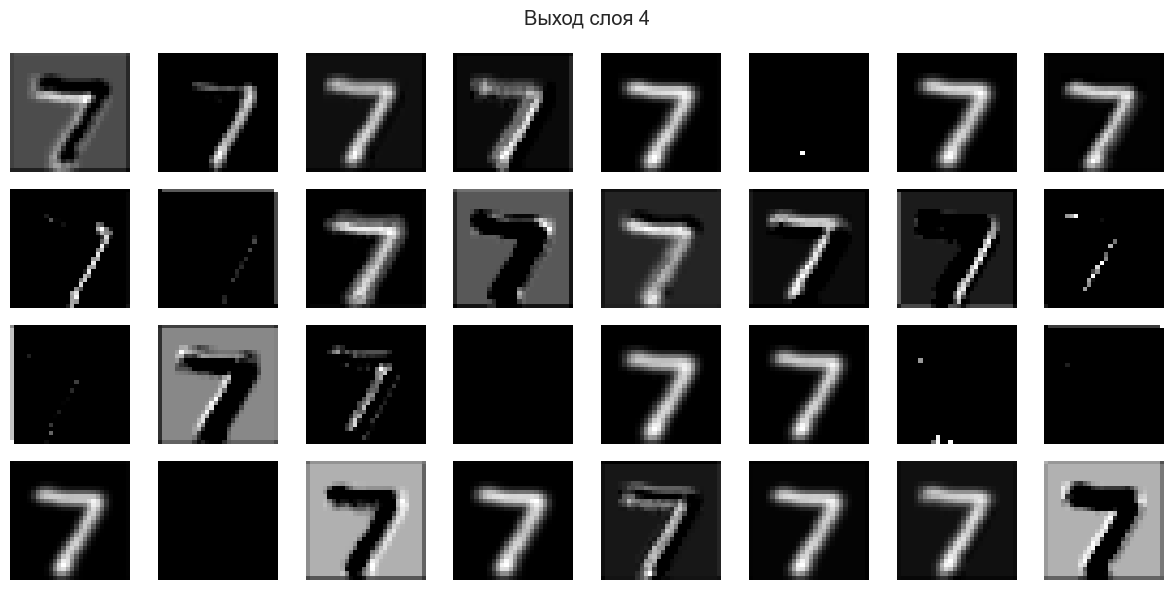

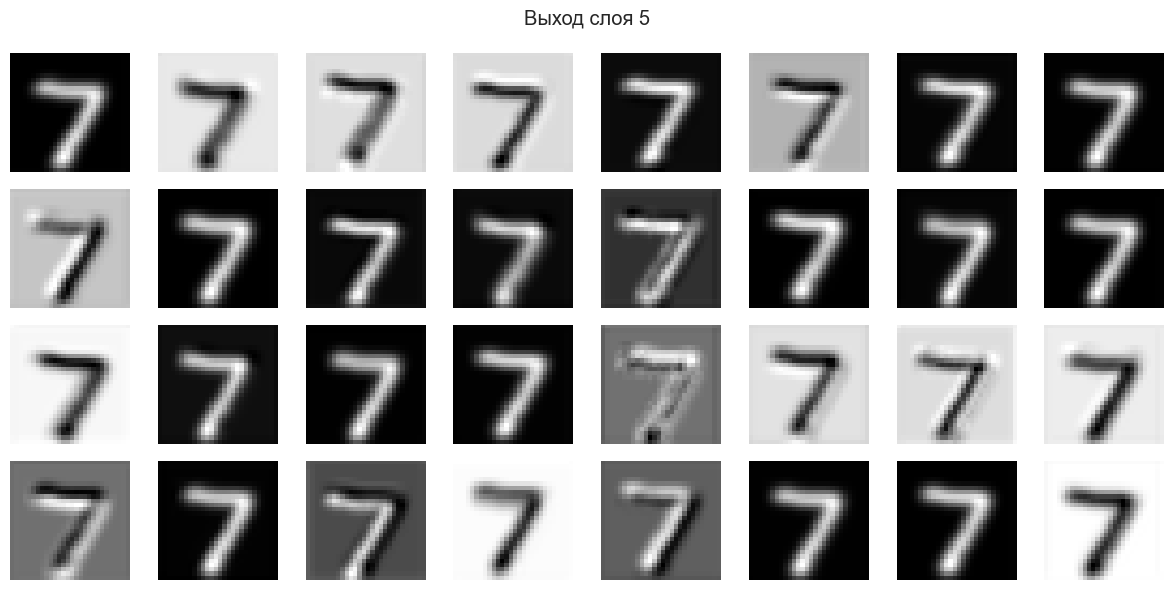

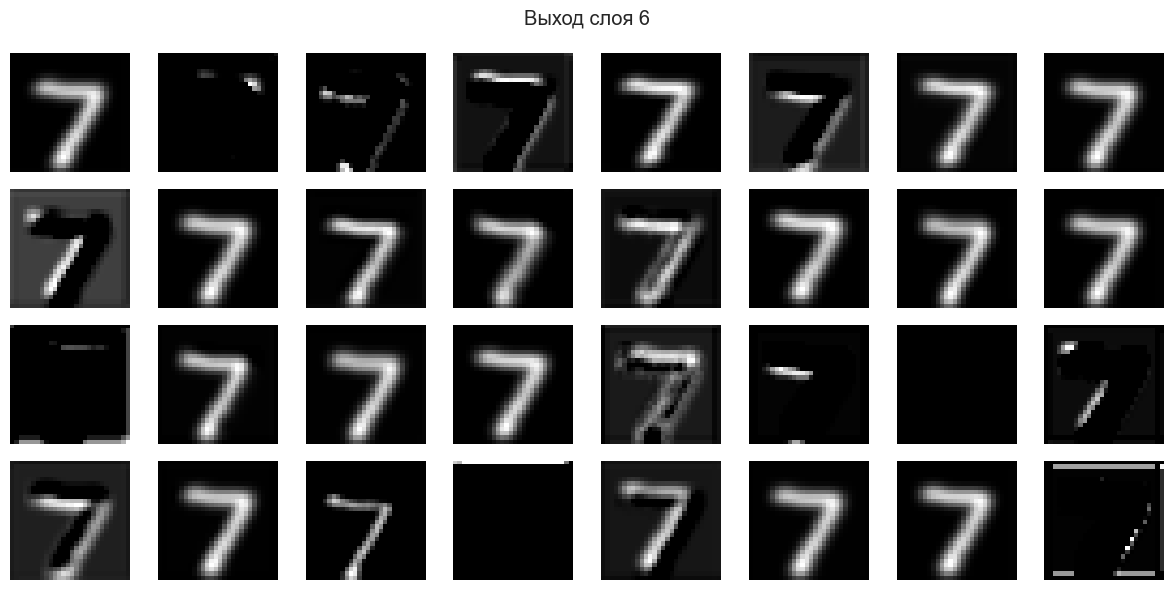

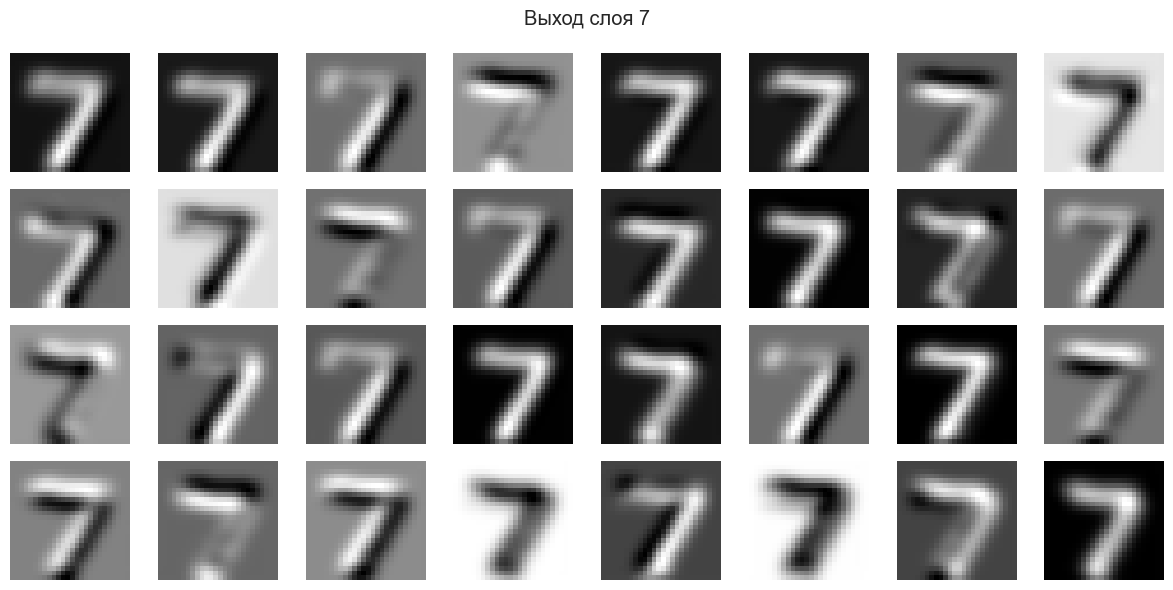

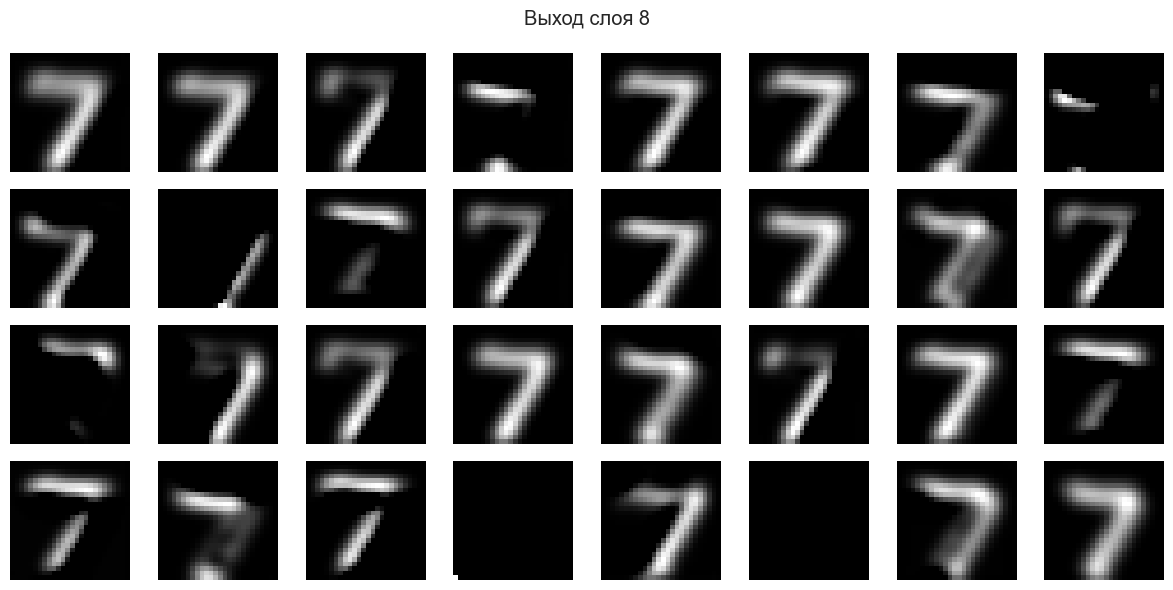

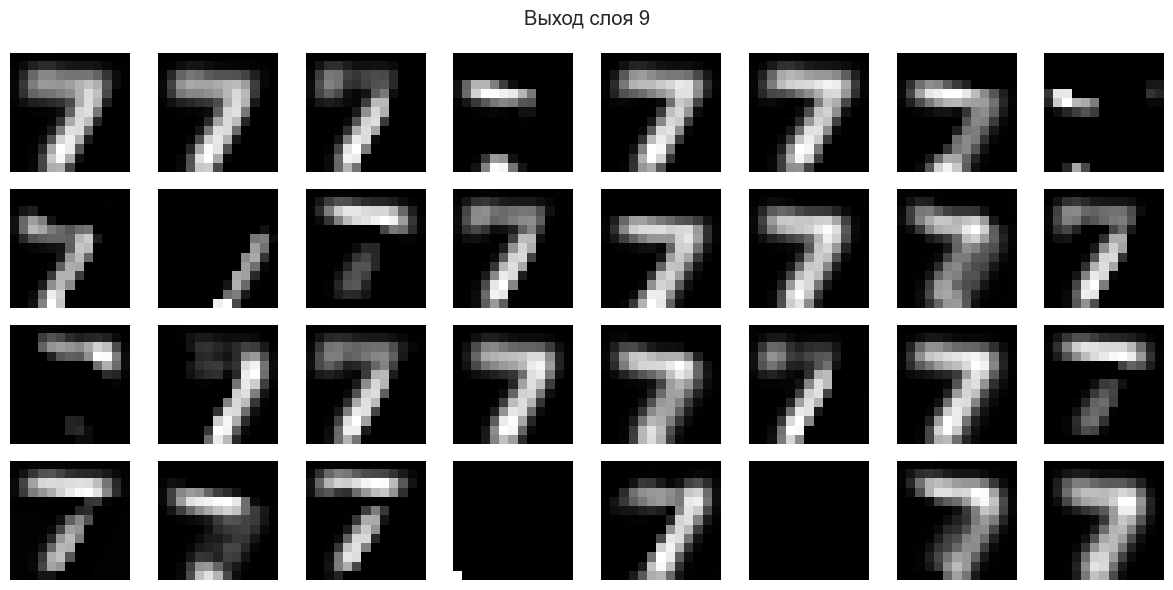

In [18]:
image, label = val_dataset[0]
image = image.unsqueeze(0).to(device)

activations = []

x = image
for i, layer in enumerate(model):
    if i > 10:
        break
    x = layer(x)
    if isinstance(layer, (nn.Conv2d, nn.ReLU, nn.MaxPool2d)):
        activations.append(x.cpu().detach())

for i, act in enumerate(activations):
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    fig.suptitle(f'Выход слоя {i+1}')
    for j, ax in enumerate(axes.flat):
        ax.imshow(act[0, j], cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Нейросеть как будто применяет фильтр Гаусса и выжеляет границы у цифры, работает отдельно с разными частями (в некоторых случаях явно видно как "ножка" отделяется от "шляпки"), ещё смотрит на особенности внутри кусков (есть места, где выделяются определенные части "ножки") и отдельно выделяет углы (тоже в некоторых случаях видно, как выделятся углы).

Визуализируйте, какие объекты, подаваемые на вход нейросети, в наибольшей степени активируют нейроны в сверточных слоях.

In [ ]:
# При реализации запрещено пользоваться ИИ-инструментами.

def visualize_filter(
    model: nn.Module,
    layer_index: int,
    target_kernel: int,
    learning_rate: float = 1,
    steps: int = 10_000,
    image_size: int = 28,
    device: Union[str, torch.device] = "cpu",
) -> torch.Tensor:
    """Визуализирует фильтр сверточного слоя нейронной сети путем оптимизации
    входного изображения, которое максимизирует активацию заданного фильтра.

    Параметры:
        model (nn.Module): Модель нейронной сети, содержащая целевой сверточный слой.
        layer_index (int): Индекс целевого сверточного слоя в модели (по порядку в model.children()).
        target_kernel (int): Индекс фильтра в целевом слое для визуализации.
        learning_rate (float, optional): Скорость обучения для оптимизатора. По умолчанию 1.
        steps (int, optional): Количество шагов оптимизации. По умолчанию 10000.
        image_size (int, optional): Размер стороны квадратного входного изображения. По умолчанию 28.
        device (str|torch.device, optional): Устройство для вычислений ('cpu' или 'cuda'). По умолчанию "cpu".

    Возвращает:
        torch.Tensor: Оптимизированное изображение (тензор формы [1, C, H, W]),
                     которое максимизирует активацию целевого фильтра.
    """

    model.eval().to(device)  # Переводим модель в режим оценки

    # Инициализируем изображение случайным шумом
    input_img = torch.randn(1, 1, image_size, image_size, requires_grad=True, device=device)
    # Обратите внимание, что в данном случае мы оптимизируем не модель, а входную картинку
    optimizer = optim.SGD([input_img], lr=learning_rate)

    # Функция потерь: максимизируем активацию нужного ядра свертки
    for step in range(steps):

        optimizer.zero_grad()

        # Пропускаем изображение через модель
        x = input_img
        for i, layer in enumerate(model):
            x = layer(x)
            if i == layer_index:
                break
            

        output = x  # Выход заданного сверточного слоя
        activation = output[0, target_kernel, :, :]
        loss = -activation.mean()  # Минимизируемая функция

        # Обратное распространение
        loss.backward()
        optimizer.step()

        # Ограничиваем значения пикселей в разумных пределах
        input_img.data = torch.clamp(input_img.data, -1, 1)

        # Логируем лосс
        if step % 500 == 0:
            print(f"Step {step}/{steps}, Loss: {loss.item():.4f}")


    # Преобразуем оптимизированное изображение
    img = input_img.detach().cpu().squeeze()

    return img

In [20]:
filter_images = []

for layer_idx, layer in enumerate(model):
    if isinstance(layer, nn.Conv2d):
        num_filters = layer.out_channels
        layer_images = []

        print(f"Визуализация слоя {layer_idx}, фильтров: {num_filters}")

        for filter_idx in range(num_filters):
            img = visualize_filter(
                model=model,
                layer_index=layer_idx,
                target_kernel=filter_idx,
                steps=1000,  # можно меньше для скорости
                learning_rate=1.0,
                device=device
            )
            layer_images.append(img)

        filter_images.append((layer_idx, layer_images))

Визуализация слоя 0, фильтров: 32
Step 0/1000, Loss: -0.2282
Step 500/1000, Loss: -0.2766
Step 0/1000, Loss: 0.0915
Step 500/1000, Loss: -0.2716
Step 0/1000, Loss: 0.3490
Step 500/1000, Loss: -0.0052
Step 0/1000, Loss: -0.1666
Step 500/1000, Loss: -0.9285
Step 0/1000, Loss: -0.2118
Step 500/1000, Loss: -0.5175
Step 0/1000, Loss: 0.2302
Step 500/1000, Loss: -0.0770
Step 0/1000, Loss: 0.3013
Step 500/1000, Loss: 0.2813
Step 0/1000, Loss: 0.1602
Step 500/1000, Loss: 0.1510
Step 0/1000, Loss: 0.2651
Step 500/1000, Loss: 0.1694
Step 0/1000, Loss: 0.2917
Step 500/1000, Loss: 0.1818
Step 0/1000, Loss: 0.2582
Step 500/1000, Loss: 0.0810
Step 0/1000, Loss: 0.0910
Step 500/1000, Loss: -1.1643
Step 0/1000, Loss: -0.2728
Step 500/1000, Loss: -0.7169
Step 0/1000, Loss: 0.0264
Step 500/1000, Loss: -0.0888
Step 0/1000, Loss: 0.1049
Step 500/1000, Loss: 0.0796
Step 0/1000, Loss: 0.0770
Step 500/1000, Loss: -0.0979
Step 0/1000, Loss: 0.0213
Step 500/1000, Loss: -0.6694
Step 0/1000, Loss: 0.0486
Step 50

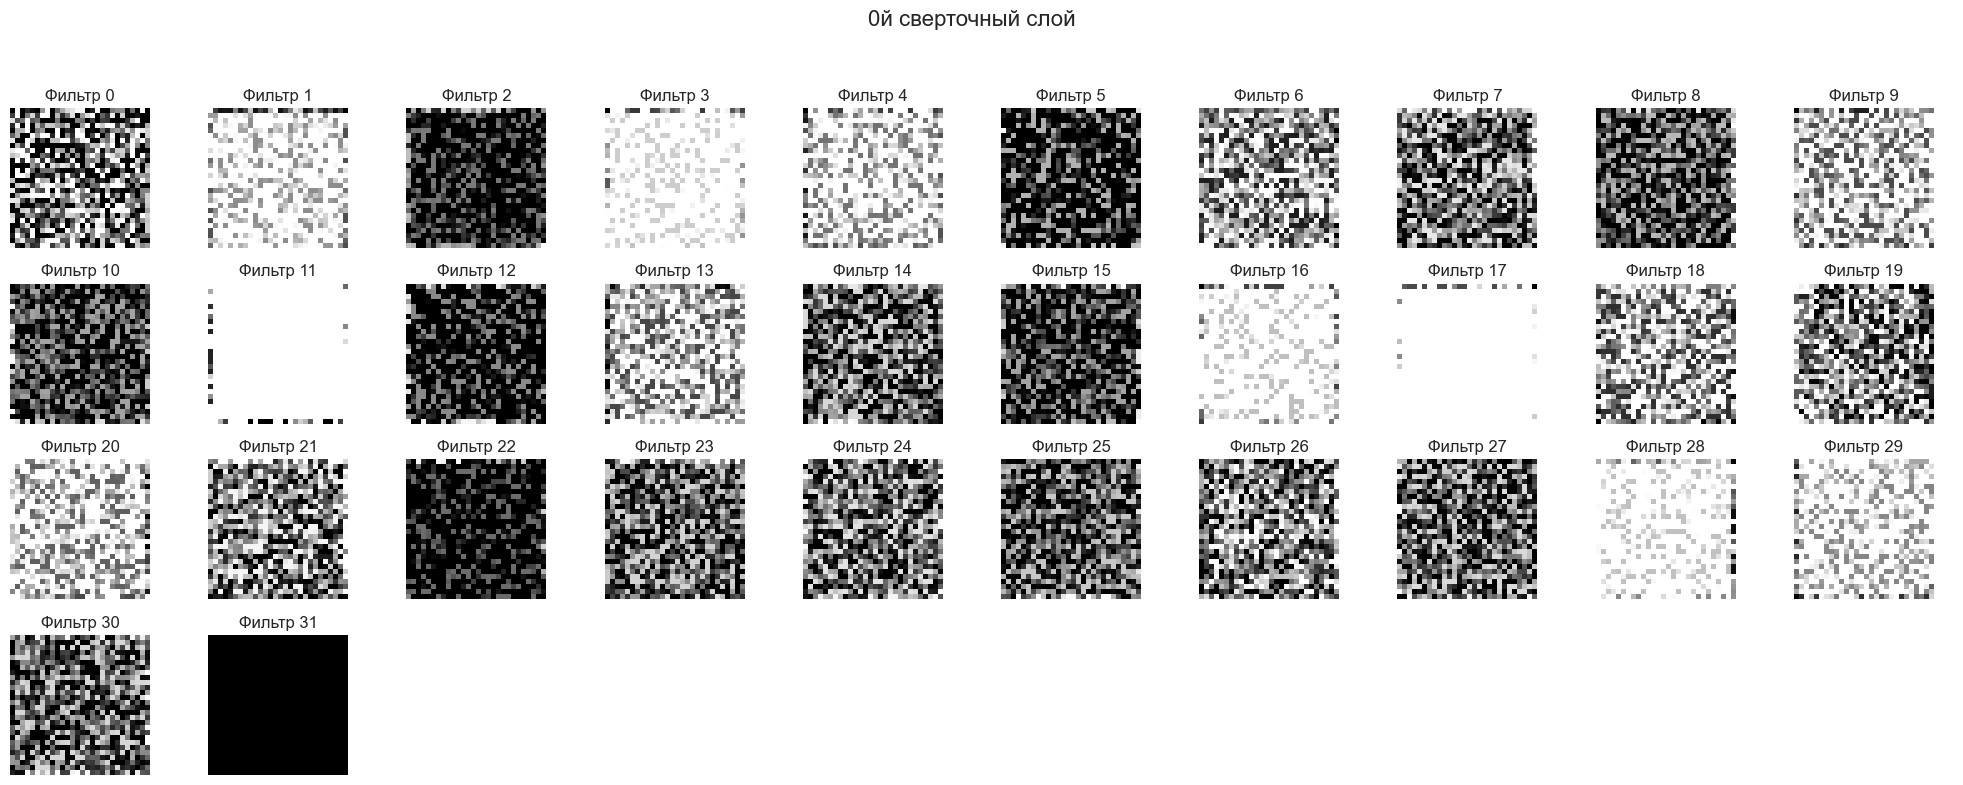

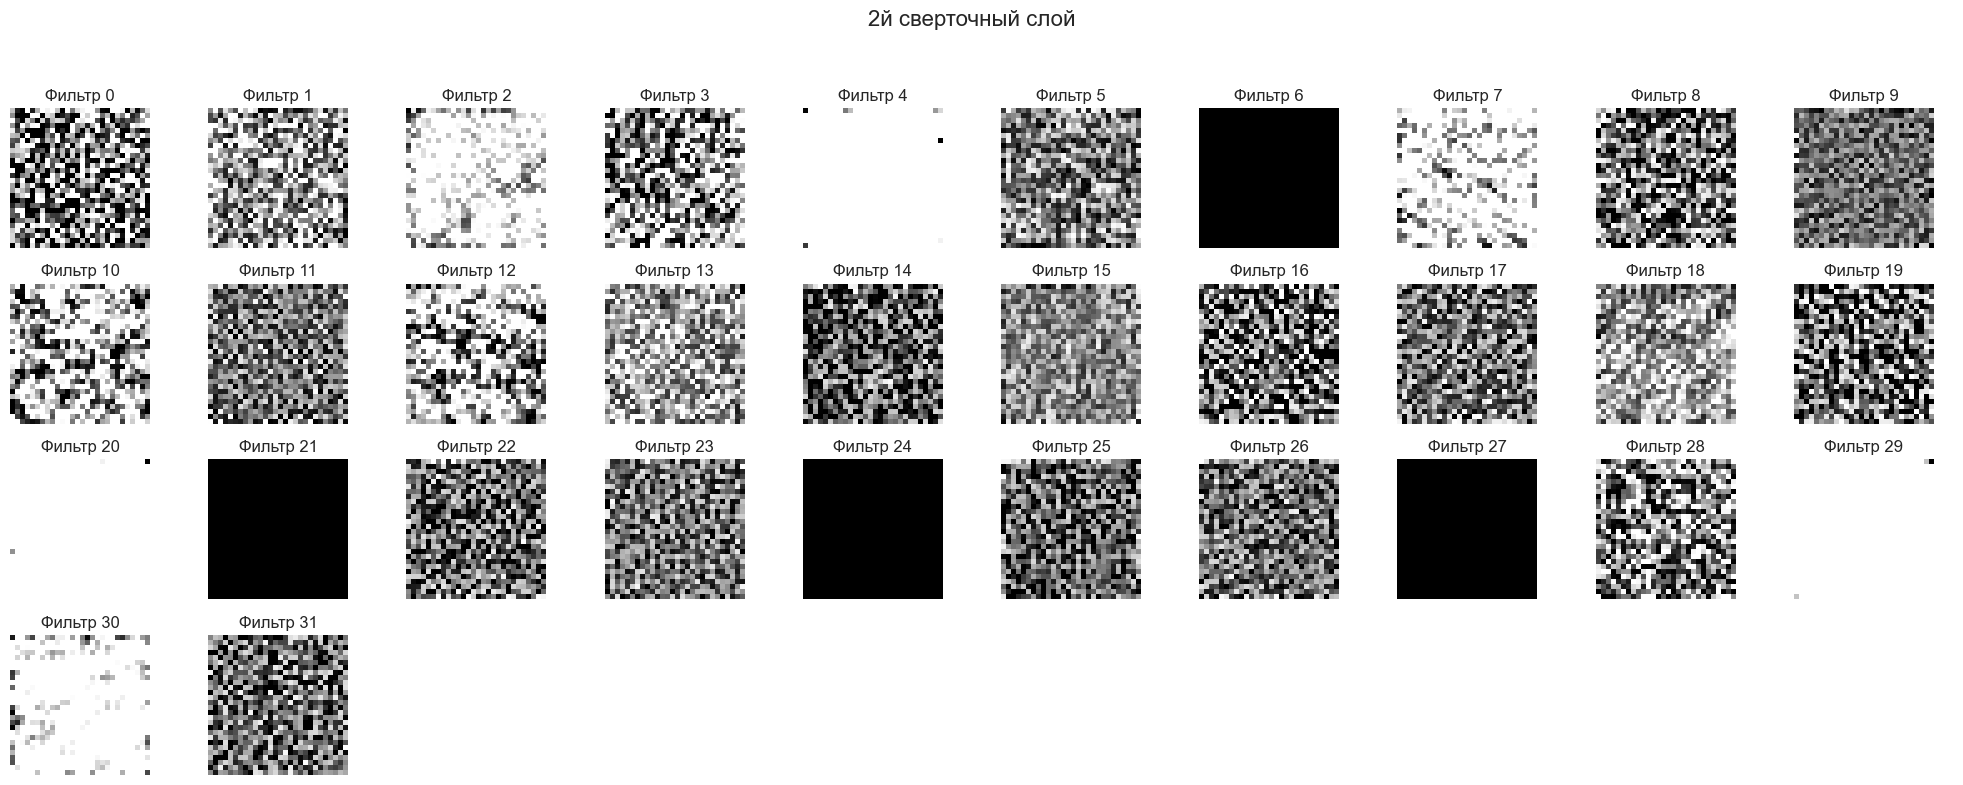

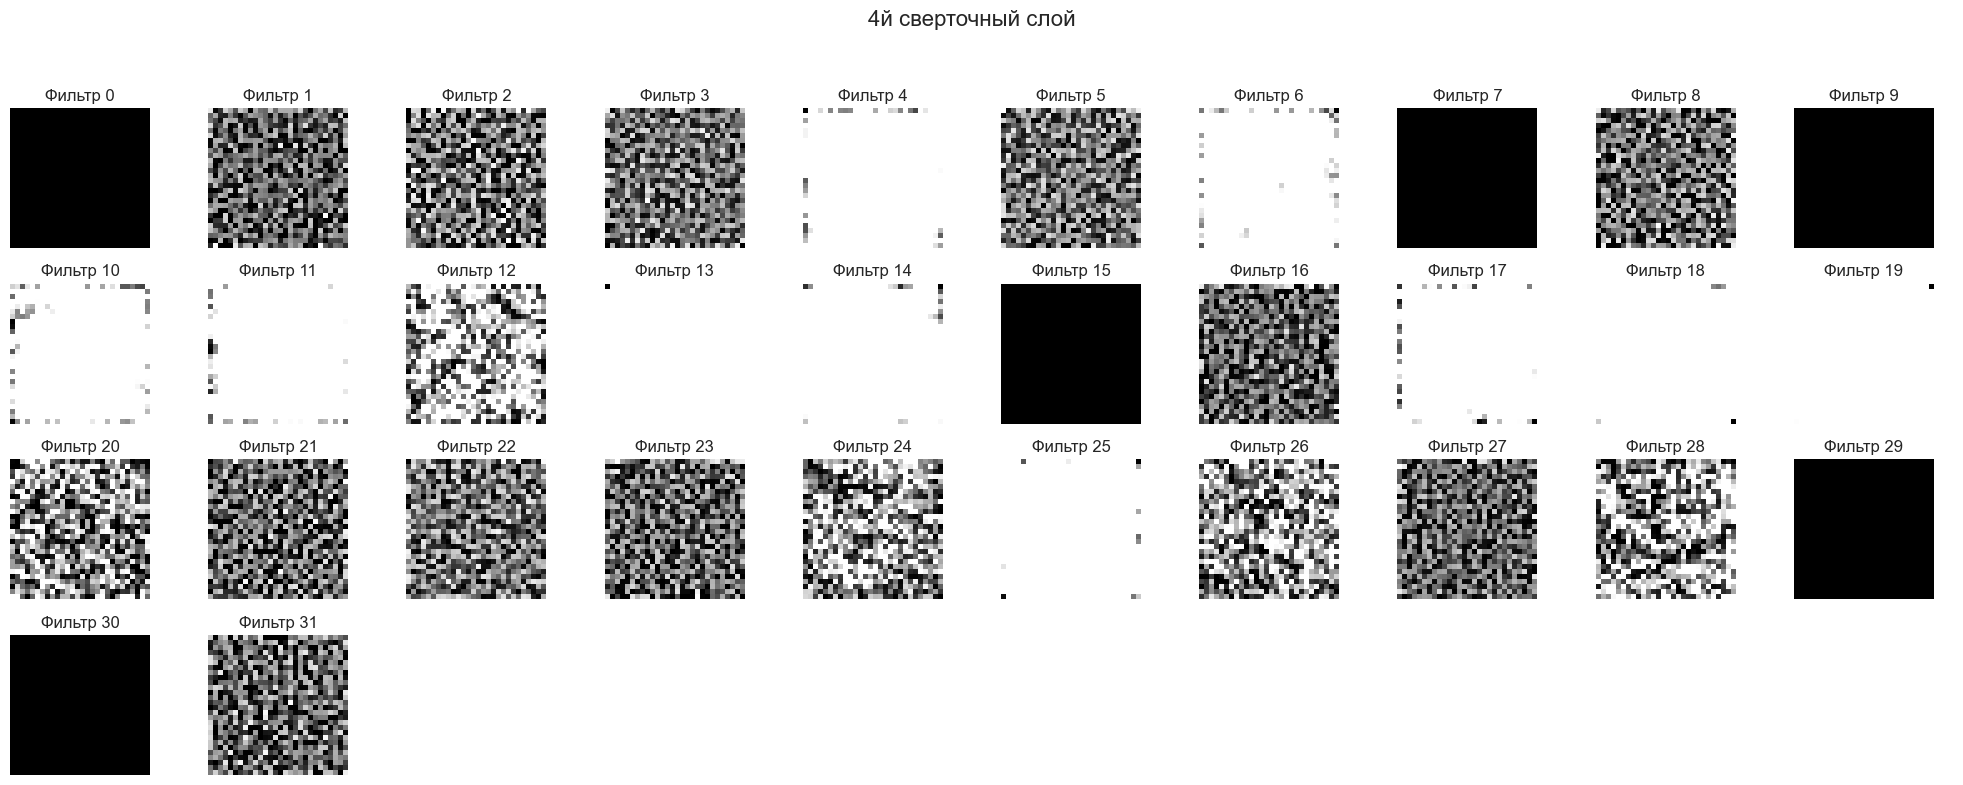

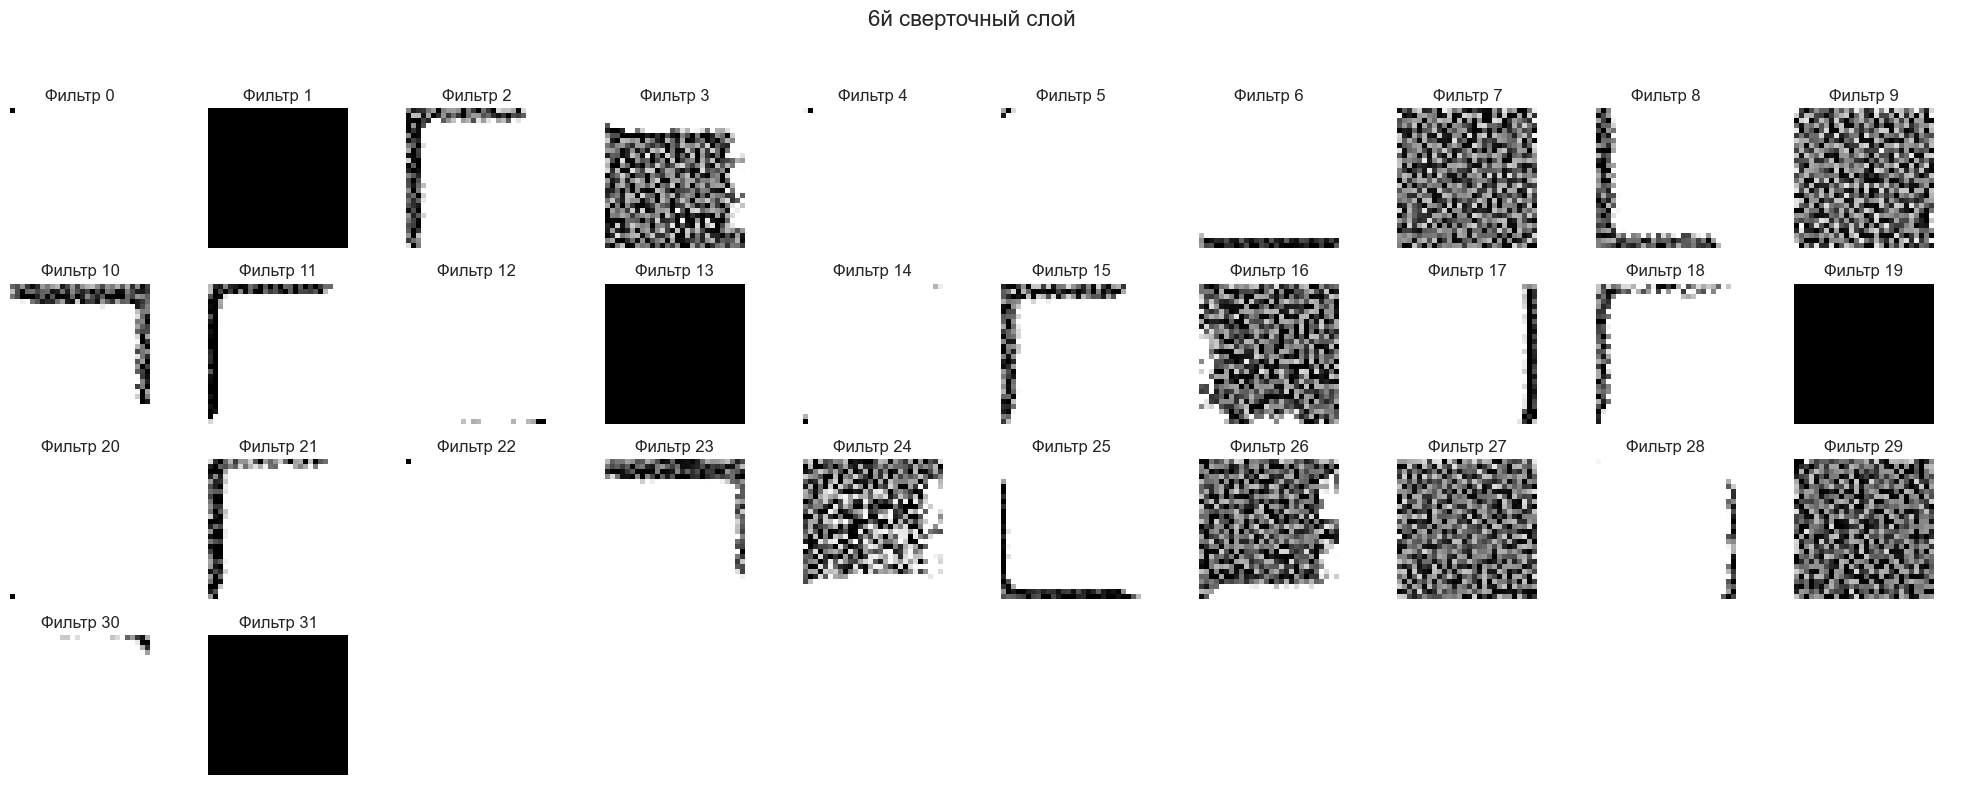

In [24]:
for layer_idx, layer_imgs in filter_images:
    num_filters = len(layer_imgs)
    cols = 10
    rows = (num_filters + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    for i in range(rows * cols):
        ax = axes[i]
        if i < num_filters:
            img = layer_imgs[i].numpy()
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Фильтр {i}")
        ax.axis("off")
    plt.suptitle(f"{layer_idx}й сверточный слой", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Первые несколько слоев выделяют совсем маленькие особенности, потому что картинки кажется без какой бы то ни было системы, затем становится все более понятно, что происходит на картинках, это значит, что слои анализируют более крупные особенности цифр.